# Supercooling in the Model Output

The degree of supercooling is given by

$$ \Delta T_{SC} = T_F - T $$


We distinguish between 
- **model potential supercooling**: with $T_F$ as the (constant) model freezing point -1.9
- **physical potential supercooling**: with $T=T_{pot}$ and $T_F = T_F(p=0,S)$ (physical surface-referenced freezing point)
- **in-situ supercooling**: with $T=T_{in-situ}$ and $T_F = T_F(p,S)$ (physical in-situ freezing point)

## Import Packages & Load Data

In [1]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

In [27]:
model_run = "MSL007"
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # open dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")
print(ds["T"].min().values)

-2.0005


In [28]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (XC: 594, YC: 66, XG: 594, YG: 66, Z: 99, Zp1: 100, Zu: 99,
              Zl: 99, time: 19)
Coordinates: (12/34)
  * XC       (XC) >f4 2kB 2.0 6.0 10.0 14.0 ... 2.366e+03 2.37e+03 2.374e+03
  * YC       (YC) >f4 264B 2.0 6.0 10.0 14.0 18.0 ... 250.0 254.0 258.0 262.0
  * XG       (XG) >f4 2kB 0.0 4.0 8.0 12.0 ... 2.364e+03 2.368e+03 2.372e+03
  * YG       (YG) >f4 264B 0.0 4.0 8.0 12.0 16.0 ... 248.0 252.0 256.0 260.0
  * Z        (Z) >f4 396B -0.5 -1.5 -2.5 -3.5 ... -360.0 -370.0 -380.0 -390.5
  * Zp1      (Zp1) >f4 400B 0.0 -1.0 -2.0 -3.0 ... -365.0 -375.0 -385.0 -396.0
    ...       ...
    dxV      (YG, XG) >f4 157kB dask.array<chunksize=(66, 594), meta=np.ndarray>
    rhoRef   (Z) >f4 396B dask.array<chunksize=(99,), meta=np.ndarray>
    dyF      (YC, XC) >f4 157kB dask.array<chunksize=(66, 594), meta=np.ndarray>
    dyU      (YG, XG) >f4 157kB dask.array<chunksize=(66, 594), meta=np.ndarray>
    dxF      (YC, XC) >f4 157kB dask.array<chunksize=(66, 594), meta=np.ndarray>
    iter     (time) int64 152B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    PH       (time, Z, YC, XC) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
    Eta      (time, YC, XC) float32 3MB dask.array<chunksize=(1, 66, 594), meta=np.ndarray>
    T        (time, Z, YC, XC) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
    W        (time, Zl, YC, XC) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
    U        (time, Z, YC, XG) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
    V        (time, Z, YG, XC) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
    S        (time, Z, YC, XC) float32 295MB dask.array<chunksize=(1, 99, 66, 594), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../../MITgcm/...

## Model Potential Supercooling

To calculate the model potential supercooling we only need the (constant) model freezing point `Tfreezing` and the potential temperature, which is already included in the model output.

In [29]:
Tfreezing = -1.9
ds["modelSC"] = (Tfreezing-ds["T"])
ds["modelSC"].attrs["standard_name"] = "model_supercooling"
ds["modelSC"].attrs["long_name"] = "Model Supercooling"
ds["modelSC"].attrs["units"] = "degrees_Celsius"

## Physical Potential Supercooling

To calculate the physical potential supercooling we need the surface freezing point and the potential temperature, which is already included in the model output.

In [30]:
Tfreezing_p0 = gsw.t_freezing(ds["S"], 0, 0)
ds["potSC"] = (Tfreezing_p0-ds["T"])
ds["potSC"].attrs["standard_name"] = "potential_supercooling"
ds["potSC"].attrs["long_name"] = "Potential Supercooling"
ds["potSC"].attrs["units"] = "degrees_Celsius"


## In-Situ Supercooling

To calculate the in-situ supercooling we need to first calculate
- the in situ temperature
- the in-situ freezing point

In-situ temperature:



In [31]:
# conservative temperature
ds["CT"] = gsw.CT_from_pt(ds["S"], ds["T"])
# calculate sea pressure
ds["p"] = ds["PH"] + ds["PHrefC"]
ds["T_situ"]=gsw.t_from_CT(ds["S"], ds["CT"], ds["p"])

In [32]:
# freezing point
ds["T_f"] = gsw.t_freezing(ds["S"], ds["p"], 0) # what about oxygen saturation fraction?

# in situ supercooling
ds["insituSC"] = ds["T_f"] - ds["T_situ"]
ds["insituSC"].attrs["standard_name"] = "in_situ_supercooling"
ds["insituSC"].attrs["long_name"] = "In Situ Supercooling"
ds["insituSC"].attrs["units"] = "degrees_Celsius"

if this gets slow: `gsw.t_freezing_poly(SA, p, saturation_fraction)` is a faster implementation that should still be accurate enough (see gsw documentation)

## Plot Lead View

In [33]:
# crop to lead view
x_min = 0.0
x_max = 1190.0
mask = (ds["XC"] >= x_min) & (ds["XC"] <= x_max)
ds_sub = ds.where(mask, drop=True)

In [9]:
print("Max. model supercooling: ", ds_sub["modelSC"].max().values)
print("Max. potential supercooling: ", ds_sub["potSC"].max().values)
print("Max. in situ supercooling: ", ds_sub["insituSC"].max().values)

Max. model supercooling:  0.10049999
Max. potential supercooling:  0.1387260301702784
Max. in situ supercooling:  0.1348812003505797


In [10]:
# monodirectional colormap (we set cmin=0 for this)
var = "modelSC"
fig = cube_time_evol(ds_sub, var, model_run, colorscale="ice_r", grid=False)

filename = "animation_" + model_run + "_" + var + "_" + ".html"
fig.write_html(filename)
print(filename)
# fig.show(renderer="browser") # works in vscode, not in jupyterhub

animation_MSL008_modelSC_.html


## Supercooling Time Series

In [34]:
ds_lead = ds.isel(XC=slice(285, 310)) # or .sel with slice(1142, 1238) in terms of physical coordinates
ds_lead_mean = ds_lead.mean(dim = ["XC", "YC", "XG","YG"])

In [10]:
ds_lead_mean.insituSC.values

array([[-3.86328069e-03, -1.15728473e-02, -1.92877985e-02, ...,
        -5.47952591e+00, -5.57205144e+00, -5.66943607e+00],
       [ 2.96845280e-02,  5.44098382e-03, -7.20336554e-03, ...,
        -5.47952362e+00, -5.57204787e+00, -5.66943769e+00],
       [ 3.55273112e-02,  8.61844577e-03, -4.83972492e-03, ...,
        -5.47952654e+00, -5.57204670e+00, -5.66944064e+00],
       ...,
       [ 1.34420192e-01,  7.01112760e-02,  4.81009790e-02, ...,
        -5.47950043e+00, -5.57122486e+00, -5.67057270e+00],
       [ 1.34466190e-01,  8.13605748e-02,  5.84557786e-02, ...,
        -5.47905690e+00, -5.57093388e+00, -5.67061515e+00],
       [ 8.53509852e-02,  5.54249986e-02,  4.93628774e-02, ...,
        -5.47907946e+00, -5.57097721e+00, -5.67067852e+00]],
      shape=(19, 99))

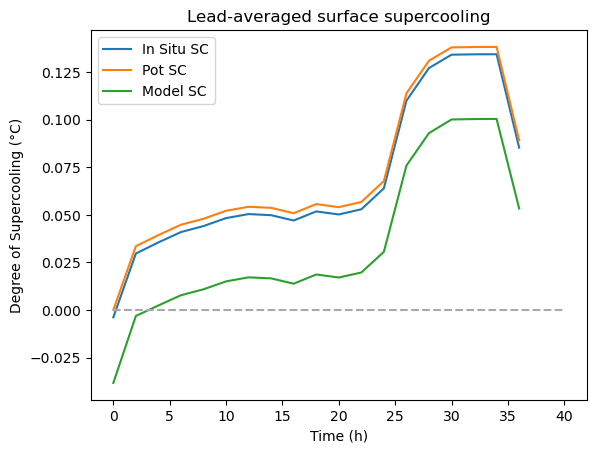

In [13]:
# plot supercooling

plot = False # it takes a while to run this
if plot:
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.insituSC.isel(Z=0), label = "In Situ SC")
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.potSC.isel(Z=0), label = "Pot SC")
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.modelSC.isel(Z=0), label = "Model SC")
    
    plt.ylabel("Degree of Supercooling (°C)")
    plt.xlabel("Time (h)")
    plt.title("Lead-averaged surface supercooling")
    plt.hlines(0,0,40, linestyle ="dashed", color = "darkgrey")

    plt.legend()

## Depth Statistics

I want to create a plot that shows 
- the percentage of supercooled cells
- the average degree of supercooling withing those

for each depth within the lead.

In [36]:
ds_lead.Z

<xarray.DataArray 'Z' (Z: 99)> Size: 396B
array([  -0.5,   -1.5,   -2.5,   -3.5,   -4.5,   -5.5,   -6.5,   -7.5,   -8.5,
         -9.5,  -10.5,  -11.5,  -12.5,  -13.5,  -14.5,  -15.5,  -16.5,  -17.5,
        -19. ,  -21. ,  -23. ,  -25. ,  -27. ,  -29. ,  -31. ,  -33. ,  -35. ,
        -37. ,  -39. ,  -41. ,  -43. ,  -45. ,  -47. ,  -49. ,  -51. ,  -53. ,
        -55. ,  -57. ,  -59. ,  -61.5,  -64.5,  -67.5,  -70.5,  -73.5,  -76.5,
        -79.5,  -82.5,  -85.5,  -88.5,  -91.5,  -94.5,  -97.5, -100.5, -104. ,
       -108. , -112. , -116. , -120. , -124. , -128. , -132. , -136. , -140. ,
       -144. , -148.5, -153.5, -158.5, -163.5, -168.5, -173.5, -178.5, -183.5,
       -189. , -195. , -201. , -207. , -213. , -219. , -225. , -231.5, -238.5,
       -245.5, -252.5, -259.5, -266.5, -274. , -282. , -290. , -298. , -306. ,
       -314.5, -323.5, -332.5, -341.5, -350.5, -360. , -370. , -380. , -390.5],
      dtype='>f4')
Coordinates:
  * Z        (Z) >f4 396B -0.5 -1.5 -2.5 -3.5 ... -360.0 -370.0 -380.0 -390.5
    drF      (Z) >f4 396B dask.array<chunksize=(99,), meta=np.ndarray>
    PHrefC   (Z) >f4 396B dask.array<chunksize=(99,), meta=np.ndarray>
    rhoRef   (Z) >f4 396B dask.array<chunksize=(99,), meta=np.ndarray>
Attributes:
    standard_name:  depth
    long_name:      vertical coordinate of cell center
    units:          m
    positive:       down
    axis:           Z

In [37]:
# crop dataset to upper ocean
ds_lead_upper = ds_lead.sel(Z=slice(-0.5,-201.))

In [46]:
SC_depth_stats = xr.Dataset() # dataset to save depth averages and fractions

SCvars = ["insituSC", "potSC", "modelSC"] 
dims_to_reduce = ["time", "XC", "YC"] # reduce/average along these dims

for var in SCvars:
    data = ds_lead_upper[var]
    
    # Create a boolean mask for positive values
    is_positive = data > 0
    
    # Fraction of positive values: Mean of the boolean mask (True=1, False=0)
    frac = is_positive.mean(dim=dims_to_reduce)*100
    
    # Average of positive values: Mask negatives to NaN, then take mean
    mean_positive = data.where(data > 0).mean(dim=dims_to_reduce)
    
    # Add both results to the existing dataset with descriptive names
    SC_depth_stats[f"{var}_frac"] = frac
    SC_depth_stats[f"{var}_mean_positive"] = mean_positive

# saving takes a while, but is necessary for continuing
# the calculations are only performed when the data is needed for saving or plotting or similar
save = False 
if save:
    filename = model_run + "_SC_depth_stats.nc"
    SC_depth_stats.to_netcdf(filename)
    print("SC_depth_stats saved to "+filename)
else:
   print("SC_depth_stats not saved") 
SC_depth_stats

SC_depth_stats not saved


<xarray.Dataset> Size: 4kB
Dimensions:                 (Z: 75)
Coordinates:
  * Z                       (Z) >f4 300B -0.5 -1.5 -2.5 ... -189.0 -195.0 -201.0
    drF                     (Z) >f4 300B dask.array<chunksize=(75,), meta=np.ndarray>
    PHrefC                  (Z) >f4 300B dask.array<chunksize=(75,), meta=np.ndarray>
    rhoRef                  (Z) >f4 300B dask.array<chunksize=(75,), meta=np.ndarray>
Data variables:
    insituSC_frac           (Z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    insituSC_mean_positive  (Z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    potSC_frac              (Z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    potSC_mean_positive     (Z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    modelSC_frac            (Z) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    modelSC_mean_positive   (Z) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>

sh: getfattr: command not found


Text(0.5, 0.98, 'Depth Statistics of Supercooling in the Simulated Lead\n')

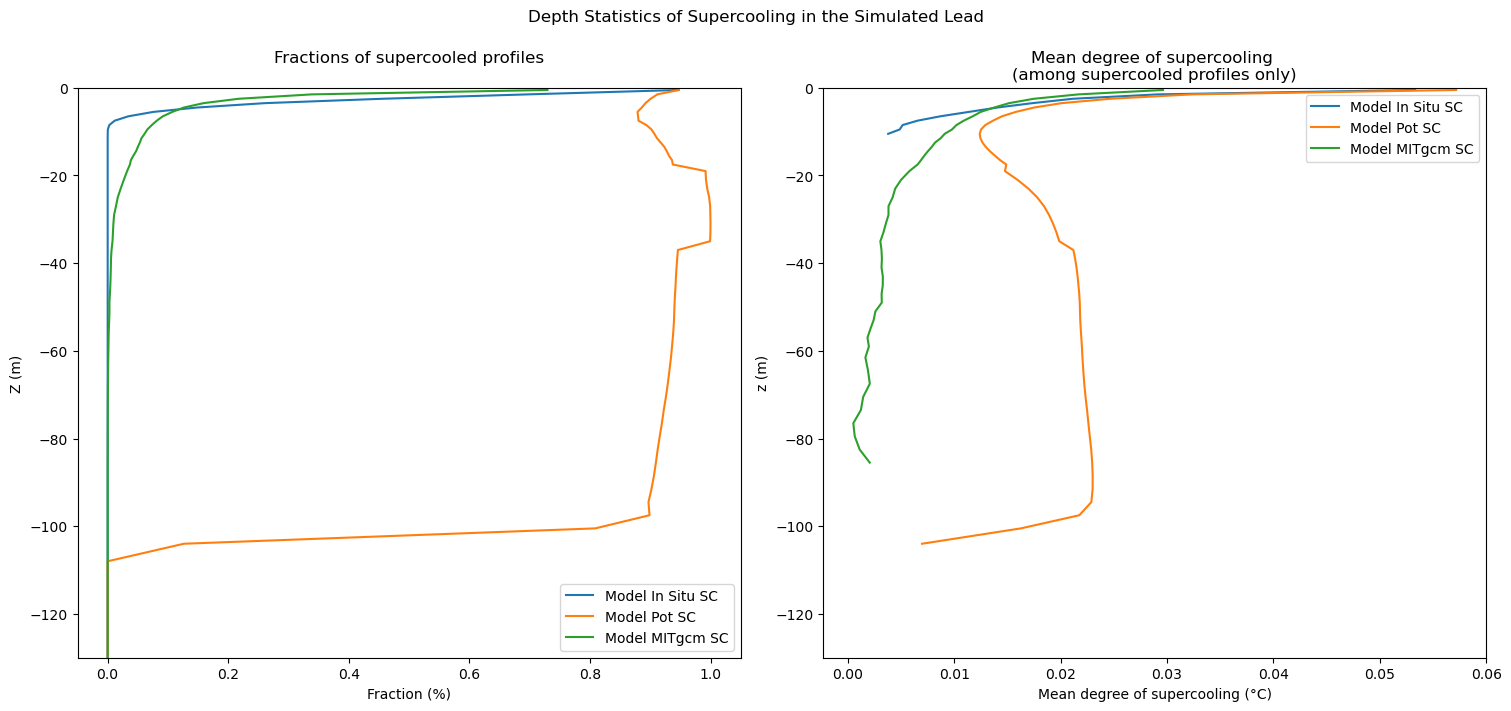

In [77]:
# Plot
filename = model_run + "_SC_depth_stats.nc"
SC_depth_stats = xr.open_dataset(filename)

fig, ax = plt.subplots(1,2, figsize = (15,7), layout = "constrained")

# Plot Supercooling Fractions
ax[0].plot(SC_depth_stats.insituSC_frac, SC_depth_stats.Z, label = "Model In Situ SC")
ax[0].plot(SC_depth_stats.potSC_frac, SC_depth_stats.Z, label = "Model Pot SC")
ax[0].plot(SC_depth_stats.modelSC_frac, SC_depth_stats.Z, label = "Model MITgcm SC")

ax[0].set_xlabel("Fraction (%)")
ax[0].set_ylabel("Z (m)")
ax[0].set_title("Fractions of supercooled profiles\n")


# plot mean supercooling
ax[1].plot(SC_depth_stats.insituSC_mean_positive, SC_depth_stats.Z, label = "Model In Situ SC")
ax[1].plot(SC_depth_stats.potSC_mean_positive, SC_depth_stats.Z, label = "Model Pot SC")
ax[1].plot(SC_depth_stats.modelSC_mean_positive, SC_depth_stats.Z, label = "Model MITgcm SC")

ax[1].set_xlabel("Mean degree of supercooling (°C)")
ax[1].set_ylabel("z (m)")
ax[1].set_title("Mean degree of supercooling \n(among supercooled profiles only)")



for a in ax:
    a.set_ylim(-130,0)

ax[0].legend()
ax[1].legend()

plt.suptitle("Depth Statistics of Supercooling in the Simulated Lead\n")

sh: getfattr: command not found


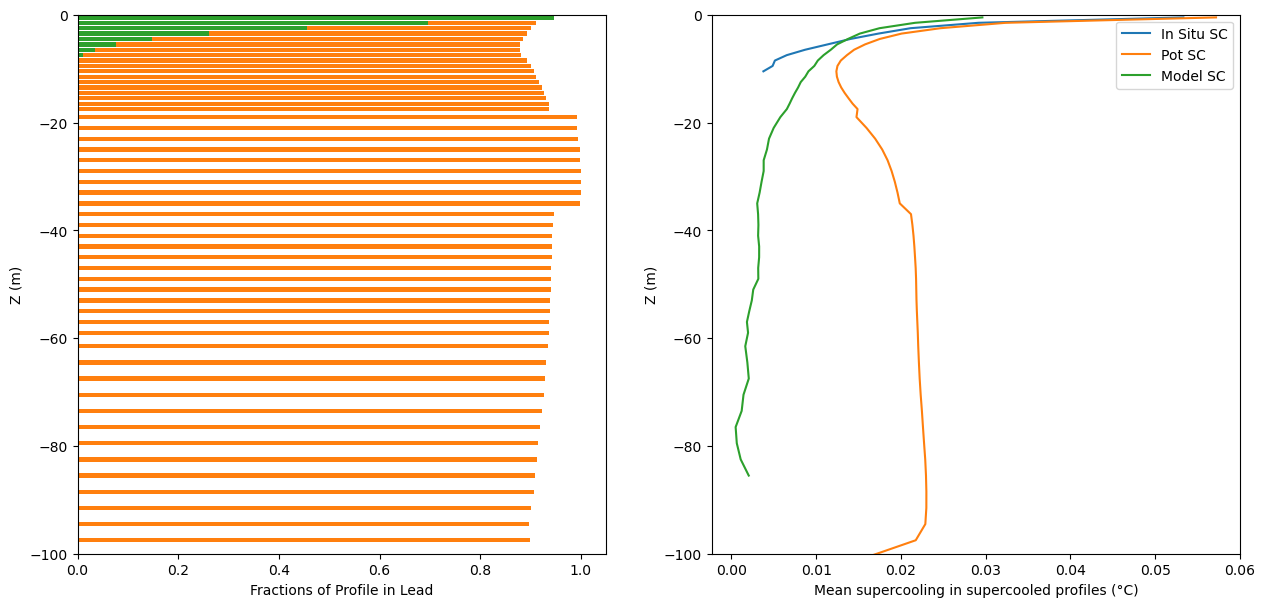

In [57]:
# Plot
filename = model_run + "_SC_depth_stats.nc"
SC_depth_stats = xr.open_dataset(filename)

fig, ax = plt.subplots(1,2, figsize = (15,7))

# Plot Supercooling Fractions
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.modelSC_frac, label = "Model SC")
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.potSC_frac, label = "Pot SC")
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.insituSC_frac, label = "In Situ SC")



ax[0].set_xlabel("Fractions of Profile in Lead")
ax[0].set_ylabel("Z (m)")


# plot mean supercooling
ax[1].plot(SC_depth_stats.insituSC_mean_positive, SC_depth_stats.Z, label = "In Situ SC")
ax[1].plot(SC_depth_stats.potSC_mean_positive, SC_depth_stats.Z, label = "Pot SC")
ax[1].plot(SC_depth_stats.modelSC_mean_positive, SC_depth_stats.Z, label = "Model SC")

ax[1].set_xlabel("Mean supercooling in supercooled profiles (°C)")
ax[1].set_ylabel("Z (m)")


for a in ax:
    a.set_ylim(-100,0)

plt.legend()

